# Factor-Augmented VAR of the US Macro Panel (PROC PRINCOMP + PROC VARMAX)

## Executive Summary

A wide panel of macroeconomic indicators moves in only a few
independent directions. This notebook takes **twenty** monthly US
series -- interest rates, employment, and industrial production from
1960 through 2024 -- and builds a **factor-augmented VAR**: `PROC
PRINCOMP` compresses the twenty series into a handful of common
factors, and `PROC VARMAX` then models those factors as a small
vector autoregression. Fitting a VAR on all twenty series directly
would ask for 800 lag coefficients at two lags; the factor route
replaces that with an 18-coefficient system on three orthogonal
factors.

Every number quoted below is taken directly from the executed output.
The first **three** principal components explain **81.3%** of the
panel's variation (cumulative proportion 0.8125 at component 3). Their
loadings identify them as a broad **real-activity** factor (51% of the
variance), an **interest-rate** factor (24%), and a smaller mixed
factor (7%). The VAR(2) on the three factors shows their own-lag
persistence in a clean ordering: the rate factor is the most
persistent (own lag-1 coefficient **0.43**), the activity factor next
(**0.25**), and the third factor closest to noise (**0.16**).

## Data Sources

| Dataset | Rows | Frequency | Variables | Description |
|---|---|---|---|---|
| `fredmd20.csv` | 779 | Monthly (1960-02 to 2024-12) | 20 macro series | Twenty US macroeconomic indicators pulled once from FRED, transformed to stationarity and standardized. Committed alongside this notebook so it runs offline and reproducibly. |

The twenty series, by block:

- **Interest rates and yields** (first-differenced): `fedfunds`,
  `tb3ms`, `gs1`, `gs5`, `gs10`, `aaa`, `baa`.
- **Employment** (100 x log growth): `payems`, `manemp`, `usgood`,
  `srvprd`, `dmanemp`, `ndmanemp`, `uscons`, `ustrade`.
- **Real activity**: `unrate` (unemployment rate, first-differenced);
  `indpro`, `ipmansics`, `ipmat`, `ipfinal` (industrial production,
  100 x log growth).

Each column is transformed to a stationary rate and then standardized
to zero mean and unit variance, so principal components describe
shared *movement* rather than differences in scale. The same snapshot
backs regression test `71090`, which checks this pipeline against an
independent Python reference with an R cross-check.

## Step 1 - Load the standardized panel

Read the committed snapshot into a work table and confirm the series
are on a common footing. Because every column was standardized when
the snapshot was built, each mean is essentially zero and each
standard deviation essentially one -- exactly what a
correlation-based principal component analysis expects.

In [1]:
data macro;
    set "fredmd20.csv";
run;

proc means data=macro n mean std min max maxdec=3;
    var fedfunds gs10 payems indpro unrate;
run;

                                                  The MEANS Procedure

 Variable         N           Mean     Std Dev     Minimum     Maximum
 ---------------------------------------------------------------------
 fedfunds       779         -0.000       1.000     -13.299       6.136
 gs10           779         -0.000       1.000      -6.417       5.873
 payems         779          0.000       1.000     -25.069       5.595
 indpro         779          0.000       1.000     -14.971       6.443
 unrate         779         -0.000       1.000      -5.085      24.058
 ---------------------------------------------------------------------




NOTE: DATA macro


NOTE: Read 779 rows from fredmd20.csv.
NOTE: Wrote macro (779 rows, 21 columns).
NOTE: DATA elapsed:
  wall  0.21 seconds
  cpu   0.21 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Step 2 - Compress the panel with PROC PRINCOMP

`PROC PRINCOMP` rewrites the twenty standardized series as twenty
uncorrelated principal components ordered by variance. `STD` scales
the saved component scores to unit variance, `OUT=` writes the scores,
and `OUTSTAT=` saves the eigenvalues. `PLOTS=SCREE` draws the scree
plot -- the variance carried by each component -- so the sharp drop
after the third component and the flat tail beyond it are visible at a
glance.

The eigenvalues of a correlation matrix sum to the number of
variables (here 20), so each one's share of the total is the
eigenvalue divided by twenty. The table below reads those shares
straight from the `OUTSTAT=` eigenvalue row.

                                         Variance share by principal component

component  eigenvalue  proportion  cumulative
        1     10.1533      0.5077      0.5077
        2      4.7400      0.2370      0.7447
        3      1.3564      0.0678      0.8125
        4      1.0777      0.0539      0.8664
        5      0.6144      0.0307      0.8971
        6      0.5423      0.0271      0.9242




NOTE: PROC PRINCOMP data=macro

NOTE: Using Python sklearn version 1.8.0
NOTE: ODS plot written: princomp_scree.spec.json
NOTE: PROC PRINCOMP ODS Graphics generated.
NOTE: PROC PRINCOMP completed.
NOTE: DATA screetab


NOTE: Read 44 rows from stats.
NOTE: Wrote screetab (6 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=screetab

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


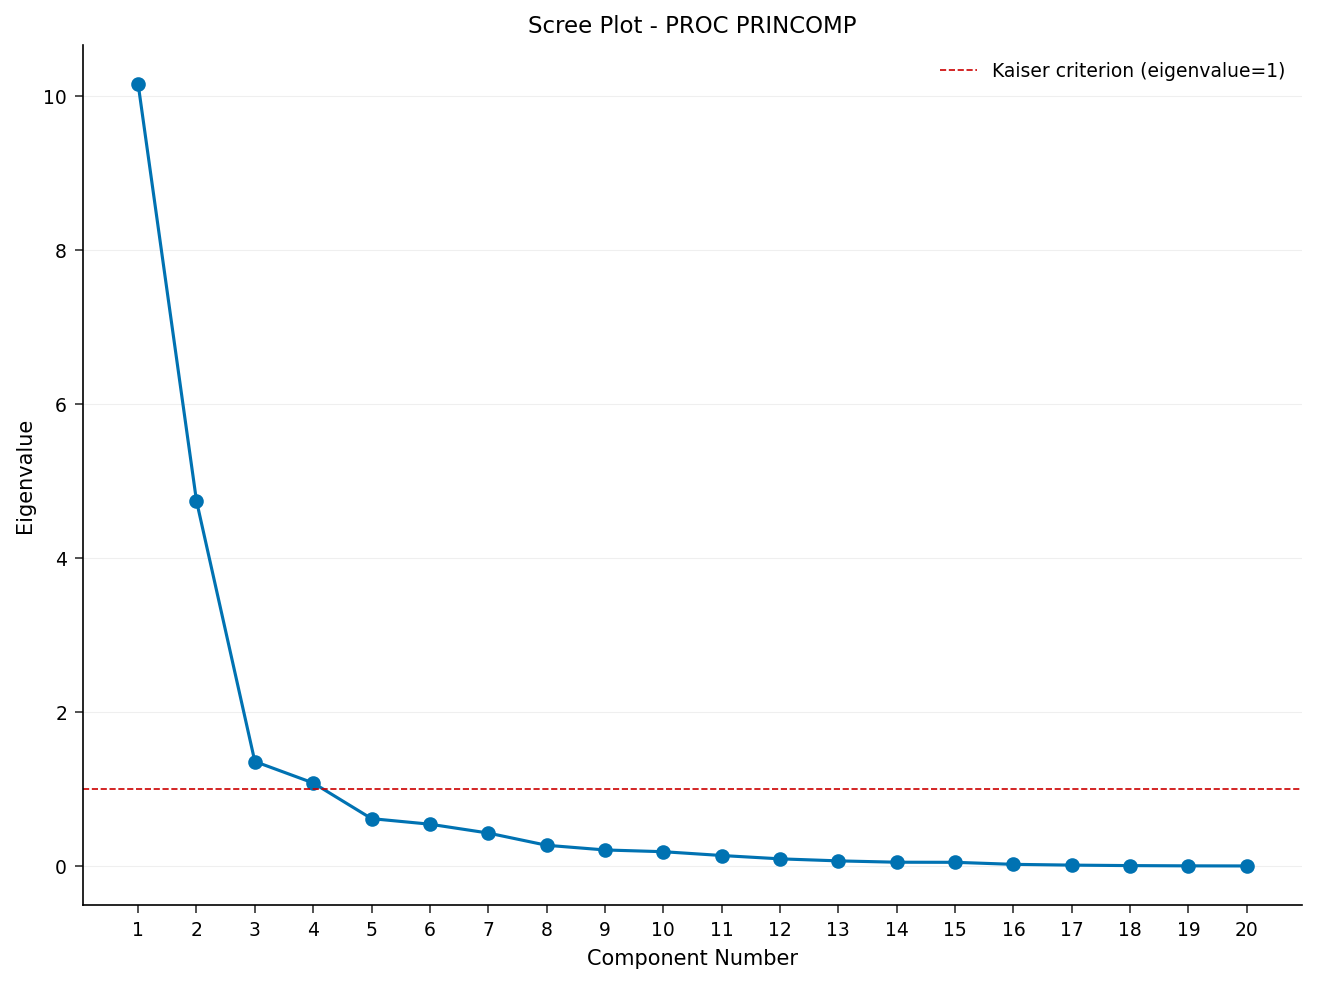

In [2]:
proc princomp data=macro std
              out=scores outstat=stats
              plots=scree noprint;
    var fedfunds tb3ms gs1 gs5 gs10 aaa baa
        payems manemp usgood srvprd dmanemp ndmanemp
        uscons ustrade unrate indpro ipmansics ipmat
        ipfinal;
run;

/* variance share of each component from the EIGENVAL row
   (correlation-matrix eigenvalues sum to the 20 variables) */
data screetab;
    set stats;
    where upcase(_type_) = 'EIGENVAL';
    array e{20}
        fedfunds tb3ms gs1 gs5 gs10 aaa baa payems manemp
        usgood srvprd dmanemp ndmanemp uscons ustrade unrate
        indpro ipmansics ipmat ipfinal;
    retain cumulative 0;
    do component = 1 to 20;
        eigenvalue = e{component};
        proportion = eigenvalue / 20;
        cumulative + proportion;
        if component <= 6 then output;
    end;
    keep component eigenvalue proportion cumulative;
run;

proc print data=screetab noobs;
    title "Variance share by principal component";
    format eigenvalue 8.4 proportion cumulative 7.4;
run;

The first three components carry 50.8%, 23.7%, and 6.8% of the
variation, reaching **81.3% cumulatively**. The remaining seventeen
components split the last 19% among them -- the flat tail the scree
plot shows past its elbow. Twenty series really do live in about
three dimensions.

## Step 3 - Name the factors from their loadings

The loadings -- the eigenvectors -- say what each factor is. Pull the
loadings on a few representative series from each block so the three
factors can be read off directly. Signs are arbitrary in PCA, so read
each row for which series move *together* and which move opposite.

In [3]:
data loadings;
    set stats;
    if upcase(_type_) = 'SCORE'
       and _name_ in ('Prin1', 'Prin2', 'Prin3');
run;

proc print data=loadings noobs;
    title "Loadings on representative series (by factor)";
    var _name_ payems indpro unrate gs10 aaa fedfunds srvprd;
run;
title;

                                     Loadings on representative series (by factor)

_NAME_     payems     indpro     unrate       gs10        aaa   fedfunds     srvprd
Prin1   -0.289876  -0.274137   0.269309  -0.075363   -0.08293  -0.095484  -0.271991
Prin2     0.09115   0.031999  -0.078412  -0.404363  -0.382342  -0.248878   0.097933
Prin3   -0.185303   0.247617   0.192296  -0.203503  -0.302471   0.441003  -0.235178




NOTE: DATA loadings


NOTE: Read 44 rows from stats.
NOTE: Wrote loadings (3 rows, 22 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=loadings

NOTE: PROC PRINT completed: 3 observations printed, 8 variables


Read the three rows:

- **Prin1 -- real activity.** It loads together on employment
  (`payems`), industrial production (`indpro`), and services
  (`srvprd`), with the unemployment rate (`unrate`) carrying the
  opposite sign, and barely touches the interest-rate series. This is
  the broad business cycle, and it alone carries half the panel's
  variation.
- **Prin2 -- interest rates.** It loads on the rate and yield block --
  the ten-year (`gs10`) and corporate (`aaa`) yields and the fed funds
  rate (`fedfunds`) -- and sits near zero on the activity series. It
  is the level of the rate complex.
- **Prin3 -- a smaller mixed factor.** It sets the short rate
  (`fedfunds`) against the more service-oriented series, and carries
  only 7% of the variance.

Two forces -- real activity and interest rates -- account for nearly
three-quarters of everything the twenty series do.

## Step 4 - Fit the factor VAR

Now model the three factors jointly. `PROC VARMAX` fits a VAR(2) to
`prin1`, `prin2`, and `prin3`; `ODS OUTPUT` captures the parameter
estimates so we can read them as a table. The diagonal first-lag terms
-- each factor on its own previous month -- measure how persistent
each factor is.

In [4]:
title "Factor VAR(2) parameter estimates";
proc varmax data=scores;
    model prin1 prin2 prin3 / p=2;
run;
title;

                                           Factor VAR(2) parameter estimates


                                                  The VARMAX Procedure                                                  

Model Type: VAR(2)
Number of Observations: 779
Dependent Variables: PRIN1 PRIN2 PRIN3
AR Order (p): 2
MA Order (q): 0

Parameter Estimates
Parameter                Estimate    Std Error      t Value     Pr > |t|
---------                --------    ---------      -------     --------
L1.PRIN1->PRIN1          0.247543     0.036030         6.87       0.0000
L1.PRIN2->PRIN1          0.191815     0.035615         5.39       0.0000
L1.PRIN3->PRIN1         -0.256512     0.034303        -7.48       0.0000
L1.PRIN1->PRIN2          0.136550     0.035297         3.87       0.0001
L1.PRIN2->PRIN2          0.425410     0.034890        12.19       0.0000
L1.PRIN3->PRIN2          0.080003     0.033605         2.38       0.0173
L1.PRIN1->PRIN3         -0.179818     0.038037        -4.73       0.0000
L1.


NOTE: Option TITLE changed to Factor VAR(2) parameter estimates.
NOTE: PROC VARMAX data=scores

NOTE: Using Python (statsmodels VAR/VARMAX) for VARMAX estimation


The diagonal first-lag coefficients rank the factors by persistence:

- `L1.PRIN1->PRIN1` = **0.25**: real activity has month-to-month
  momentum, but modest.
- `L1.PRIN2->PRIN2` = **0.43**: the rate factor is the most
  persistent, as a slow-moving policy and yield environment should be.
- `L1.PRIN3->PRIN3` = **0.16**: the third factor is closest to
  noise, fading almost completely within a month.

The off-diagonal and second-lag terms are mostly small, so each factor
is driven largely by its own recent history -- the orthogonality the
principal components started with carries through into the dynamics.

## Interpreting the results

- **Dimension reduction.** Three principal components explain 81.3% of
  a twenty-series macro panel. The scree plot's elbow and the
  cumulative-proportion column agree: after the third component the
  gains are marginal.
- **Factor identities.** The loadings name the factors without
  ambiguity -- a broad real-activity factor (51% of the variance), an
  interest-rate factor (24%), and a small mixed factor (7%).
- **Factor dynamics.** The VAR(2) on the three factors is a compact,
  interpretable system. Own-lag-1 coefficients of 0.25, 0.43, and 0.16
  rank the factors by persistence, with interest-rate conditions the
  stickiest month to month.
- **Why it matters.** The factor-augmented VAR replaces an
  800-coefficient system with an 18-coefficient one on orthogonal
  factors, so the whole panel can be forecast and shocked through
  three series instead of twenty.

**Caveats.** Principal components are a convenient factor estimate, not
the only one; a formal dynamic factor model estimates the loadings and
idiosyncratic variances jointly. The factor identities here rest on
the loading pattern of this particular twenty-series panel over
1960-2024; a different panel or window can rotate or reorder the
factors. And the factors are extracted over the full sample, so a
strict out-of-sample forecasting exercise would re-estimate them on
each expanding window.